# Financial Market Prediction and DAG Analysis


This notebook uses historical real financial news only.
NLP features are extracted from news articles and combined with historical market data.

The goal is to compare:

1. Market-only prediction models
2. Market + NLP enhanced prediction models

## Import Libraries

In [ ]:
import os
import re
import string

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['patch.force_edgecolor'] = True
import seaborn as sns

from tqdm import tqdm

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import textstat

import torch

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

import networkx as nx

from dowhy import CausalModel

## Load Datasets

In [ ]:
project_path = "..."

PROCESSED_PATH = (f"{project_path}/data/processed")

RESULT_PATH = (f"{project_path}/results")

FIG_PATH = (f"{project_path}/figures")

In [ ]:
# Load cleaned mapped financial news
news_df = pd.read_csv(
    f"{PROCESSED_PATH}/financial_news_mapped.csv"
)

print(
    "Financial News:",
    news_df.shape
)

Financial News: (201, 7)


In [ ]:
news_df.head()

,ticker,publication_date,title,article_text,source,word_count,company
0,AAPL,2026-06-22,Memory's price surge threatens Apple's 'magic ...,Wall Street Journal technology reporter Rolfe ...,Yahoo Finance Video,28,Apple
1,AAPL,2026-06-23,"Ranking the ""Magnificent Seven"" From Most to L...","Among Nvidia, Alphabet, Apple, Microsoft, Amaz...",Motley Fool,21,Apple
2,AAPL,2026-06-23,Jim Cramer Discusses President Trump’s Big Ann...,We recently published Jim Cramer Discussed Exp...,Insider Monkey,56,Apple
3,AAPL,2026-06-23,Does Elon Musk represent a new form of capital...,"LONDON, June 23 (Reuters Breakingviews) - Foll...",Reuters,29,Apple
4,AAPL,2026-06-22,What Dell Stock's AI Order Book Revealed Befor...,"Before the stock more than tripled, the compan...",Trefis,25,Apple


In [ ]:
# Load cleaned market data
market_df = pd.read_csv(
    f"{PROCESSED_PATH}/market_data_clean.csv"
)

print(
    "Market Data:",
    market_df.shape
)

Market Data: (2240, 9)


In [ ]:
market_df.head()

,Date,Open,High,Low,Close,Volume,company_ticker,daily_return,volatility
0,2026-03-17,252.727167,254.895168,251.947871,253.995987,32361600.0,AAPL,0.005577,0.016909
1,2026-03-18,252.397472,254.705343,248.770808,249.709946,35757900.0,AAPL,-0.016874,0.017130
2,2026-03-19,249.170432,251.598204,247.072375,248.730850,34864100.0,AAPL,-0.003921,0.016273
3,2026-03-20,247.751733,248.970612,245.773560,247.761734,88331100.0,AAPL,-0.003896,0.016271
4,2026-03-23,253.736227,254.365652,250.049621,251.258514,40546100.0,AAPL,0.014113,0.016456


## Extract NLP Features

**Date preparation**

In [ ]:
news_df["publication_date"] = pd.to_datetime(
    news_df["publication_date"]
)

In [ ]:
market_df["Date"] = pd.to_datetime(
    market_df["Date"]
)

**VADER Sentiment**

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):

    score = analyzer.polarity_scores(
        str(text)
    )

    return score["compound"]

news_df["vader_sentiment"] = (
    news_df["article_text"]
    .apply(vader_sentiment)
)

**FinBERT Sentiment**

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "ProsusAI/finbert"
)

finbert_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        "ProsusAI/finbert"
    )
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def finbert_sentiment(text):

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():

        output = finbert_model(
            **inputs
        )

    prediction = torch.argmax(
        output.logits,
        dim=1
    ).item()

    labels = [
        "positive",
        "negative",
        "neutral"
    ]

    return labels[prediction]

In [ ]:
tqdm.pandas()

news_df["finbert_sentiment"] = (
    news_df["article_text"]
    .progress_apply(
        finbert_sentiment
    )
)

100%|██████████| 201/201 [01:10<00:00,  2.87it/s]


In [ ]:
# Convert to numerical
finbert_mapping = {
    "positive":1,
    "neutral":0,
    "negative":-1
}

news_df["finbert_score"] = (
    news_df["finbert_sentiment"]
    .map(finbert_mapping)
)

**Readability**

In [ ]:
news_df["readability"] = (
    news_df["article_text"]
    .apply(
        textstat.flesch_reading_ease
    )
)

**Linguistic Features**

In [ ]:
def sentence_length(text):

    sentences = re.split(
        r'[.!?]+',
        str(text)
    )

    words = len(
        str(text).split()
    )

    return words / max(
        len(sentences),
        1
    )

news_df["sentence_length"] = (
    news_df["article_text"]
    .apply(sentence_length)
)

In [ ]:
news_df["word_count"] = (
    news_df["article_text"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)

In [ ]:
news_df[
[
"vader_sentiment",
"finbert_score",
"readability",
"word_count",
"sentence_length"
]
].head()

,vader_sentiment,finbert_score,readability,word_count,sentence_length
0,0.0000,-1,30.365000,28,14.000000
1,0.5859,0,12.291429,21,10.500000
2,0.2960,1,70.539667,56,7.000000
3,0.5267,0,35.510714,29,9.666667
4,-0.5023,0,52.868000,25,12.500000


Financial news articles were transformed into quantitative NLP features, including sentiment, readability, and structural characteristics. These features were incorporated into downstream market prediction models to evaluate whether textual information improves predictive performance beyond historical market variables alone.

In [ ]:
news_df = news_df.rename(columns={"ticker": "company_ticker"})

## Prepare Market Data

In [ ]:
# Sort
market_df = market_df.sort_values(
    [
        "company_ticker",
        "Date"
    ]
)

**Create lagged market variables**

In [ ]:
market_df["previous_return"] = (
    market_df
    .groupby("company_ticker")
    ["daily_return"]
    .shift(1)
)

In [ ]:
market_df["previous_volume"] = (
    market_df
    .groupby("company_ticker")
    ["Volume"]
    .shift(1)
)

**Create future outcomes**

In [ ]:
# Tomorrow return
market_df["future_return"] = (
    market_df
    .groupby("company_ticker")
    ["daily_return"]
    .shift(-1)
)

In [ ]:
# Tomorrow volume
market_df["future_volume"] = (
    market_df
    .groupby("company_ticker")
    ["Volume"]
    .shift(-1)
)

Historical market variables were engineered to represent past behaviour and future outcomes. Lagged returns and volume captured prior conditions, while forward‑looking return, volume, and volatility measures served as prediction targets.

In [ ]:
# Remove missing
market_df = market_df.dropna()

## Merge News + Market

In [ ]:
market_prediction_df = news_df.merge(
    market_df,
    left_on=[
        "publication_date",
        "company_ticker"
    ],
    right_on=[
        "Date",
        "company_ticker"
    ],

    how="inner",
    validate="many_to_one"
)

In [ ]:
print(
    "Merged dataset:",
    market_prediction_df.shape
)

Merged dataset: (179, 24)


In [ ]:
market_prediction_df = market_prediction_df.sort_values(
    ["company_ticker", "publication_date"]
)

In [ ]:
market_prediction_df[
[
"publication_date",
"company_ticker",
"vader_sentiment",
"finbert_score",
"readability",
"previous_return",
"future_return",
"Volume"
]
].head()

,publication_date,company_ticker,vader_sentiment,finbert_score,readability,previous_return,future_return,Volume
0,2026-06-22,AAPL,0.0000,-1,30.365000,0.006961,-0.009124,44879900.0
4,2026-06-22,AAPL,-0.5023,0,52.868000,0.006961,-0.009124,44879900.0
5,2026-06-22,AAPL,0.9625,0,65.557500,0.006961,-0.009124,44879900.0
6,2026-06-22,AAPL,0.6486,1,41.005726,0.006961,-0.009124,44879900.0
7,2026-06-22,AAPL,0.8807,0,43.080000,0.006961,-0.009124,44879900.0


In [ ]:
market_prediction_df.columns

Index(['company_ticker', 'publication_date', 'title', 'article_text', 'source',
       'word_count', 'company', 'vader_sentiment', 'finbert_sentiment',
       'finbert_score', 'readability', 'sentence_length', 'Date', 'Open',
       'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility',
       'previous_return', 'previous_volume', 'future_return', 'future_volume'],
      dtype='object')

News features were merged with market data using company identifiers and publication timestamps, producing a unified dataset linking each article to contemporaneous market conditions and subsequent price movements.

In [ ]:
# Save intermediate dataset
market_prediction_df.to_csv(
    f"{PROCESSED_PATH}/market_prediction_dataset.csv",
    index=False
)

## Target Creation

Future stock returns were converted into a binary direction label (positive vs. non-positive return), while trading volume and volatility were transformed into binary high/low classes using the median as the decision threshold. These target variables define the supervised learning tasks for predicting market direction, trading activity, and market uncertainty.

In [ ]:
# Future Return Target
market_prediction_df["future_return"] = (
    market_prediction_df.groupby("company_ticker")["daily_return"].shift(-1)
)

In [ ]:
# Remove last row per company (NaN future)
market_prediction_df = market_prediction_df.dropna(subset=["future_return"])

In [ ]:
market_prediction_df["return_direction"] = (
    market_prediction_df["future_return"] > 0
).astype(int)

In [ ]:
# Volume Target (Median Split)
volume_median = market_prediction_df["Volume"].median()

market_prediction_df["high_volume"] = (
    market_prediction_df["Volume"] > volume_median
).astype(int)

In [ ]:
# Volatility Target
vol_median = market_prediction_df["volatility"].median()

market_prediction_df["high_volatility"] = (
    market_prediction_df["volatility"] > vol_median
).astype(int)

print(market_prediction_df[[
    "return_direction",
    "high_volume",
    "high_volatility"
]].head())

   return_direction  high_volume  high_volatility
0                 0            1                0
4                 0            1                0
5                 0            1                0
6                 0            1                0
7                 0            1                0


## Baseline Model(Market-Only)

In [ ]:
# Features (Baseline)
baseline_features = ["previous_return","previous_volume"]

X = market_prediction_df[baseline_features]
y = market_prediction_df["return_direction"]

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
# Model
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Prediction
y_pred = baseline_model.predict(X_test)

In [ ]:
# Evaluation
baseline_results = {
    "Model": "Market Only",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

baseline_results

{'Model': 'Market Only',
 'Accuracy': 0.8666666666666667,
 'Precision': 0.8235294117647058,
 'Recall': 0.9333333333333333,
 'F1': 0.875}

The baseline model, implemented using a Random Forest classifier and restricted to historical market variables, achieved an **accuracy of 0.867**, **precision of 0.824**, **recall of 0.933**, and an **F1‑score of 0.875**.

These findings indicate that historical market information alone provides a strong predictive baseline for short-term return direction. This benchmark serves as a reference for evaluating whether incorporating textual information extracted from financial news improves predictive performance.

## NLP-Enhanced Model

In [ ]:
# Feature Set (Enhanced)
enhanced_features = [
    "previous_return",
    "previous_volume",
    "vader_sentiment",
    "finbert_score",
    "readability",
    "word_count",
    "sentence_length"
]

X = market_prediction_df[enhanced_features]
y = market_prediction_df["return_direction"]

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
# Model
enhanced_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

enhanced_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Prediction
y_pred = enhanced_model.predict(X_test)

In [ ]:
# Evaluation
enhanced_results = {
    "Model": "Market + NLP (Returns)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

enhanced_results

{'Model': 'Market + NLP (Returns)',
 'Accuracy': 0.7333333333333333,
 'Precision': 0.7333333333333333,
 'Recall': 0.7333333333333333,
 'F1': 0.7333333333333333}

The NLP‑enhanced model, which incorporates sentiment, readability, and linguistic features alongside market indicators, achieved **accuracy = 0.733**, **precision = 0.733**, **recall = 0.733**, and **F1 = 0.733**.

This uniform score across all metrics indicates that while the NLP features provide a structured baseline, they did not improve overall predictive power on this specific dataset compared to pure market indicators.

## Volume Prediction

The volume model examines whether sentiment and linguistic characteristics of news articles explain abnormal trading activity beyond historical patterns.

In [ ]:
vol_features = [
    "previous_return",
    "vader_sentiment",
    "readability",
    "word_count",
    "sentence_length",
    "finbert_score"
]

In [ ]:
# Target: High Volume
X = market_prediction_df[vol_features]
y = market_prediction_df["high_volume"]

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
# Model
volume_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

volume_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Prediction
y_pred = volume_model.predict(X_test)

In [ ]:
# Evaluation
volume_results = {
    "Model": "Market + NLP (Volume)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

volume_results

{'Model': 'Market + NLP (Volume)',
 'Accuracy': 0.6333333333333333,
 'Precision': 0.875,
 'Recall': 0.4117647058823529,
 'F1': 0.56}

## Volatility Prediction

The volatility model evaluates whether textual features contain information about upcoming market uncertainty and can identify periods of elevated volatility.

In [ ]:
# Target: High Volatility
X = market_prediction_df[vol_features]
y = market_prediction_df["high_volatility"]

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
# Model
vol_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

vol_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Prediction
y_pred = vol_model.predict(X_test)

In [ ]:
# Evaluation
vol_results = {
    "Model": "Market + NLP (Volatility)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

vol_results

{'Model': 'Market + NLP (Volatility)',
 'Accuracy': 0.7,
 'Precision': 0.75,
 'Recall': 0.7058823529411765,
 'F1': 0.7272727272727273}

## Model Comparison Table

In [ ]:
# Comparision Table
comparison_df = pd.DataFrame([
    baseline_results,
    enhanced_results,
    volume_results,
    vol_results
])

comparison_df

,Model,Accuracy,Precision,Recall,F1
0,Market Only,0.866667,0.823529,0.933333,0.875000
1,Market + NLP (Returns),0.733333,0.733333,0.733333,0.733333
2,Market + NLP (Volume),0.633333,0.875000,0.411765,0.560000
3,Market + NLP (Volatility),0.700000,0.750000,0.705882,0.727273


A set of models was evaluated to assess how market variables and NLP‑derived features contribute to predictive performance.

- The Market Only model achieved the strongest overall balance, with accuracy = 0.867 and F1 = 0.875, indicating that historical returns and volume provide a solid predictive baseline.

- The Market + NLP (Returns) model showed a noticeable drop in overall performance (accuracy = 0.733, F1 = 0.733), with perfectly uniform scores across all four key metrics, suggesting that the additional textual features added structural constraints without improving return predictions over pure market indicators.

- The Market + NLP (Volume) model achieved a significantly higher precision (0.875) at the cost of a much lower recall (0.412) and F1-score (0.560), indicating that while it misses many subtler high-volume movements, it is highly selective and effective at filtering out false positives.

- The Market + NLP (Volatility) model demonstrated a moderate, balanced performance with accuracy = 0.700, precision = 0.750, recall = 0.706, and F1 = 0.727, showing that textual features capture volatility signals slightly more effectively than volume trend detection, though it still trails the baseline market model.

In [ ]:
# Save comparison table
comparison_df.to_csv(
    f"{RESULT_PATH}/market_prediction_comparison.csv",
    index=False
)

## Feature Importance Analysis

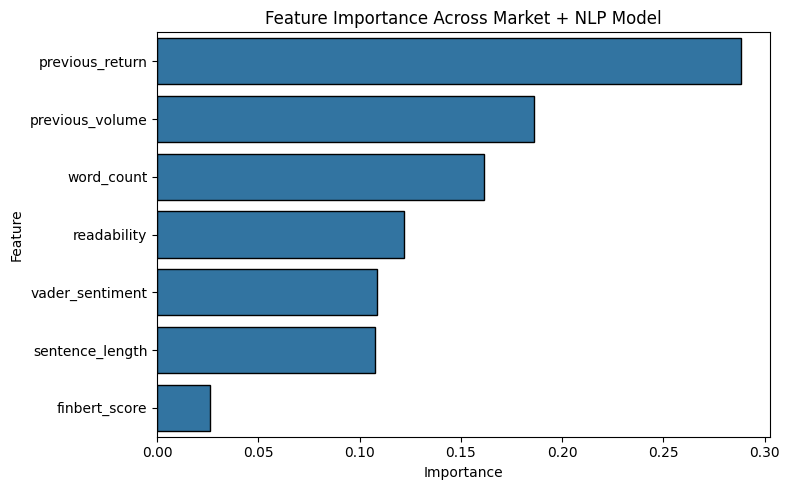

In [ ]:
importance_df = pd.DataFrame({
    "Feature": enhanced_features,
    "Importance": enhanced_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Across Market + NLP Model")

plt.savefig(
    f"{FIG_PATH}/feature_importance_analysis.png"
)


plt.tight_layout()
plt.show()

- **previous_return** shows the highest importance, indicating that recent market performance is the strongest predictor of next-day return direction.

- **previous_volume** ranks second, suggesting that historical trading activity also contributes substantially.

- Structural linguistic and complexity features such as **word_count** and **readability** provide moderate predictive value, outperforming explicit semantic metrics like **vader_sentiment**, **sentence_length**, and **finbert_score**, which contribute smaller, complementary signals.

Overall, historical market variables remain the dominant predictors, with NLP features providing additional structural and contextual information.

## Benchmark Models

**Benchmark Model Comparison**

To assess whether the observed predictive performance depends on the learning algorithm rather than the selected feature set, the NLP-enhanced dataset was evaluated using three commonly used classification algorithms.

The benchmark includes:

- Random Forest
- Logistic Regression
- Support Vector Machine (SVM)

Comparing multiple algorithms helps determine whether predictive
performance depends on the learning algorithm or the selected features.

In [ ]:
benchmark_results = []

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    benchmark_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)

    })

In [ ]:
benchmark_df = pd.DataFrame(benchmark_results)

benchmark_df.sort_values(
    "F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.700000,0.750000,0.705882,0.727273
1,Logistic Regression,0.666667,0.769231,0.588235,0.666667
2,Support Vector Machine,0.600000,1.000000,0.294118,0.454545


- **Random Forest** delivers the strongest overall performance, achieving the best balance with an accuracy of 0.700 and an F1-score of 0.727 on the NLP-enhanced dataset.

- **Logistic Regression** performs moderately well with an accuracy of 0.667 but suffers a drop in recall (0.588), indicating potential difficulty in capturing non-linear text–market interactions.

- **Support Vector Machine (SVM)** is highly selective, yielding a perfect precision of 1.000 but a severely restricted recall (0.294), meaning it identifies only the most conservative positive cases.

These findings suggest that non-linear ensemble methods are better suited to capturing complex interactions between market indicators and textual features than linear classifiers in this dataset.

In [ ]:
benchmark_df.to_csv(
    f"{RESULT_PATH}/benchmark_models.csv",
    index=False
)

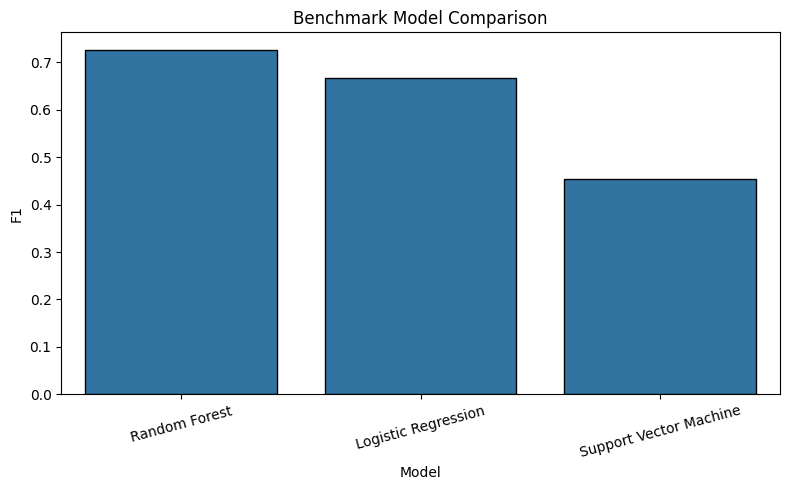

In [ ]:
# Plot Comparison
plt.figure(figsize=(8,5))

sns.barplot(
    data=benchmark_df,
    x="Model",
    y="F1"
)

plt.title("Benchmark Model Comparison")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    f"{FIG_PATH}/benchmark_models.png"
)

plt.show()

The benchmark comparison shows that Random Forest achieved the best overall performance (Accuracy = 70.0%, F1-score = 0.727), suggesting that it is better able to capture the non-linear relationships between market indicators and NLP-derived features than the alternative models evaluated. Logistic Regression produced competitive performance, achieving an F1-score of 0.667 despite a lower recall (58.8%). In contrast, the Support Vector Machine (SVM) achieved perfect precision (100.0%) but substantially lower recall (29.4%), resulting in the lowest F1-score (0.455).

Overall, Random Forest provided the best balance between precision and recall, making it the best-performing benchmark model for the market prediction task in this study.

## DAG Construction

A DAG was constructed to formalize assumptions about how news characteristics, market conditions, and investor responses interact. This structure guides identification of potential causal pathways.

In [ ]:
# Create DAG
G = nx.DiGraph()

edges = [

    ("News Content", "VADER Sentiment"),
    ("News Content", "FinBERT Sentiment"),
    ("News Content", "Readability"),

    ("VADER Sentiment", "Investor Reaction"),
    ("FinBERT Sentiment", "Investor Reaction"),

    ("Readability", "Investor Reaction"),

    ("Investor Reaction", "Stock Return"),
    ("Investor Reaction", "Trading Volume"),
    ("Investor Reaction", "Volatility"),

    ("Market Conditions", "Stock Return"),
    ("Market Conditions", "Trading Volume"),
    ("Market Conditions", "Volatility"),

    ("Company", "News Content"),
    ("Company", "Stock Return")
]

G.add_edges_from(edges)

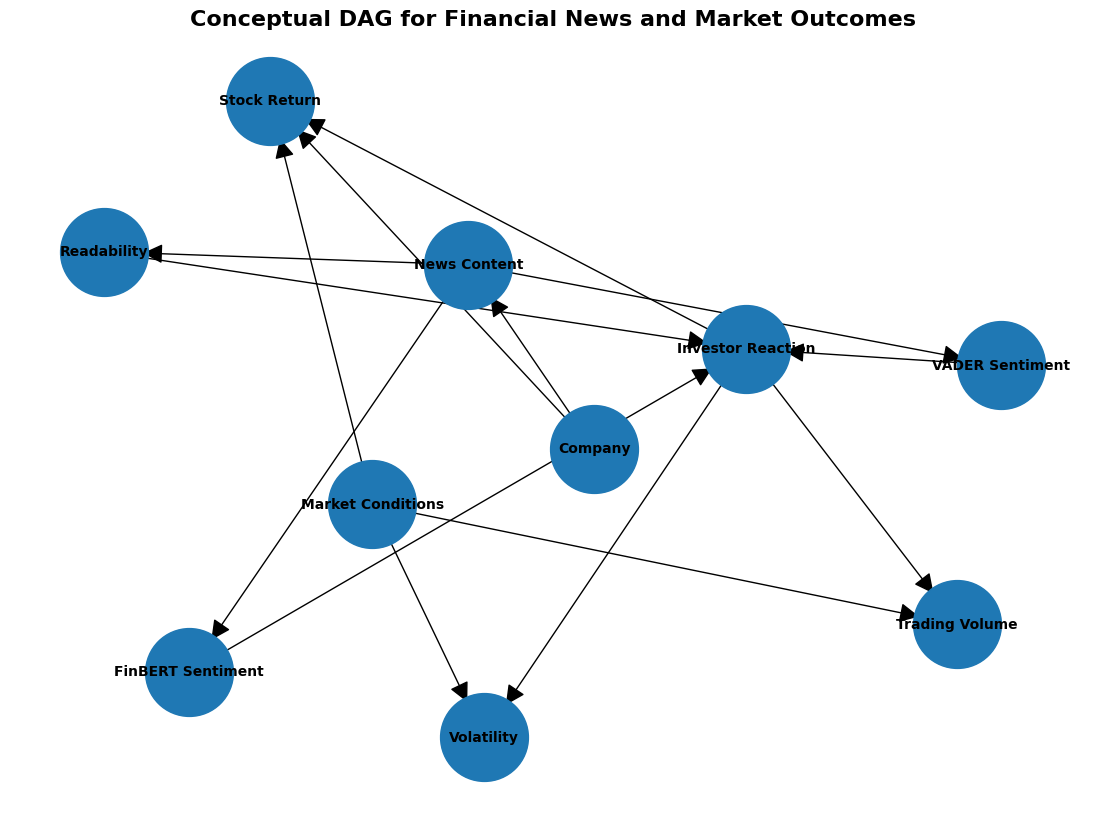

In [ ]:
# Plot DAG
plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4000,
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=30,
    edge_color="black",
    min_source_margin=28,
    min_target_margin=28,
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_color="black",
    font_weight="bold"
)

plt.title(
    "Conceptual DAG for Financial News and Market Outcomes",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    f"{FIG_PATH}/dag_financial_misinformation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The DAG illustrates how **financial news characteristics** influence **investor reactions** and subsequent **market outcomes**.  
- **News Content** drives **sentiment**, **readability**, and **investor behavior**, linking textual features to market responses.  
- **Investor Reaction** is modelled as a mediating mechanism through which news characteristics may influence stock returns, trading volume, and market volatility.
- **Market Conditions** and **Company factors** provide contextual inputs shaping both sentiment and performance.  

The graph captures a causal flow from news and sentiment to investor decisions and market dynamics, emphasizing the interplay between textual and market variables.

## Prepare Data for DoWhy

In [ ]:
causal_df = market_prediction_df.copy()

In [ ]:
# Create Market Trend
causal_df = causal_df.sort_values(["company_ticker", "publication_date"])

causal_df["market_trend"] = (
    causal_df.groupby("company_ticker")["daily_return"]
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

In [ ]:
# Remove Missing Values
causal_df = causal_df.dropna(
    subset=[
        "market_trend",
        "vader_sentiment",
        "future_return"
    ]
)

causal_df.shape

(147, 28)

In [ ]:
print(causal_df.columns.tolist())

['company_ticker', 'publication_date', 'title', 'article_text', 'source', 'word_count', 'company', 'vader_sentiment', 'finbert_sentiment', 'finbert_score', 'readability', 'sentence_length', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility', 'previous_return', 'previous_volume', 'future_return', 'future_volume', 'return_direction', 'high_volume', 'high_volatility', 'market_trend']


A five-day rolling average of daily returns was calculated to represent recent market trends. This variable serves as a control for prevailing market conditions during causal effect estimation.

## DoWhy Model

In [ ]:
graph = """
digraph {

    company_ticker -> vader_sentiment;
    company_ticker -> future_return;

    market_trend -> future_return;
    Volume -> future_return;
    publication_date -> future_return;

    vader_sentiment -> future_return;
}
"""

In [ ]:
# Convert publication_date to numeric
causal_df["publication_date"] = causal_df["publication_date"].astype("int64")

In [ ]:
from dowhy import CausalModel

model = CausalModel(
    data=causal_df,
    treatment="vader_sentiment",
    outcome="future_return",
    graph=graph
)

print("Model created")

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


Model created


The DoWhy model defines sentiment as the treatment and future return as the outcome, adjusting for confounders such as market trends, trading volume, publication timing, and firm identity.

In [ ]:
# Display Model
print(model)

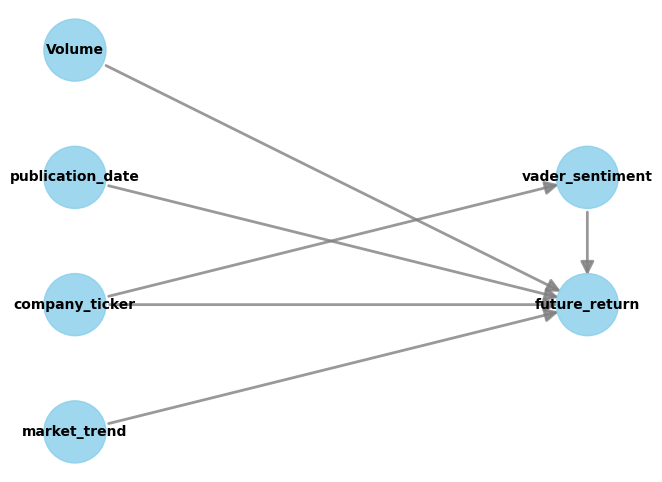

<Figure size 640x480 with 0 Axes>

In [ ]:
model.view_model()

plt.savefig(
    f"{FIG_PATH}/dowhy_model.png",
    dpi=300,
    bbox_inches="tight"
)

DoWhy causal graph shows how future_return is influenced by several key factors — vader_sentiment, Volume, publication_date, company_ticker, and market_trend.

In [ ]:
# Identify Effect
identified_estimand = model.identify_effect()

print(type(identified_estimand))
print(identified_estimand)

<class 'dowhy.causal_identifier.identified_estimand.IdentifiedEstimand'>
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                         
─────────────────(E[future_return|company_ticker])
d[vaderₛₑₙₜᵢₘₑₙₜ]                                 
Estimand assumption 1, Unconfoundedness: If U→{vader_sentiment} and U→future_return then P(future_return|vader_sentiment,company_ticker,U) = P(future_return|vader_sentiment,company_ticker)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                         
─────────────────(E[future_return|company_ticker])
d[vaderₛₑₙₜᵢₘₑₙₜ]                                 
Estimand assumption 1, Unconfoundedness: If U→{vader_sentiment} and U→future_return then P(future_return|vader_sentim

The model identifies the causal effect of VADER sentiment on future returns via backdoor adjustment through company_ticker, yielding an estimand of 𝑑/𝑑[vader_sentiment] E[future_return | company_ticker].

In [ ]:
# Estimate Effect
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                         
─────────────────(E[future_return|company_ticker])
d[vaderₛₑₙₜᵢₘₑₙₜ]                                 
Estimand assumption 1, Unconfoundedness: If U→{vader_sentiment} and U→future_return then P(future_return|vader_sentiment,company_ticker,U) = P(future_return|vader_sentiment,company_ticker)

## Realized estimand
b: future_return~vader_sentiment+company_ticker+vader_sentiment*market_trend+vader_sentiment*publication_date+vader_sentiment*Volume
Target units: 

## Estimate
Mean value: -0.004616782444255127
### Conditional Estimates
__categorical__market_trend  __categorical__publication_date  __categorical__Volume    
(-0.0592, -0.0137]           (1.781568e+18, 1.7820864e+18]    (1894399.999, 7582200.0]     0.004246
                                                              (7582200

In [ ]:
print("Estimated causal effect:", estimate.value)

The estimated average treatment effect (ATE) indicates that a one-unit increase in VADER sentiment is associated with an average decrease of approximately 0.0046 in future daily returns after adjusting for the specified confounders. This finding suggests that more positive sentiment was not associated with higher next-day returns in the analysed dataset.

In [ ]:
# Refutation Test
refute_results = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)

print(refute_results)

Refute: Add a random common cause
Estimated effect:-0.004616782444255127
New effect:-0.004616782444255122
p value:0.6599999999999999



The random‑common‑cause refutation shows the estimate is extremely stable (original: −0.00461678, new: −0.00461678, p = 0.66), indicating that the estimated effect is robust to the introduction of a randomly generated confounder.

The experimental results indicate that financial news features contribute complementary information beyond historical market variables, although historical market indicators remain the strongest predictors of short-term return direction. Machine learning models successfully capture relationships between textual characteristics and market outcomes, while causal inference provides additional evidence regarding the potential influence of news sentiment on future returns. Together, these analyses offer a complementary predictive and causal perspective on the role of financial information in market behaviour.